In [25]:
import pandas as pd
import numpy as np

In [26]:
df = pd.read_csv("DateFruit_Dataset.csv")

In [27]:
df.head() # 34 features, 1 category

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [28]:
df.shape

(898, 35)

In [29]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [30]:
df["Class"].unique()

array(['BERHI', 'DEGLET', 'DOKOL', 'IRAQI', 'ROTANA', 'SAFAVI', 'SOGAY'],
      dtype=object)

In [31]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ANN

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [35]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [36]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [37]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [38]:
# Build our Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X.shape[1], 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.model(x)

In [39]:
model = ANN()

# loss & optim
criteria = nn.CrossEntropyLoss() #cross entropy loss is used for autometically softmax is used

optimizer = optim.Adam(model.parameters())

In [40]:
# Training the ANN

epochs = 100

loss_values = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criteria(outputs, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    loss_values.append(train_loss)

    print(f"epoch = {epoch+1}/{epochs}, loss = {train_loss}")

epoch = 1/100, loss = 1.7098406397778054
epoch = 2/100, loss = 1.0965718523315762
epoch = 3/100, loss = 0.7219276505967845
epoch = 4/100, loss = 0.5364475457564645
epoch = 5/100, loss = 0.43449054204899334
epoch = 6/100, loss = 0.37156798852526624
epoch = 7/100, loss = 0.32993196987587475
epoch = 8/100, loss = 0.3064673607764037
epoch = 9/100, loss = 0.28067784756422043
epoch = 10/100, loss = 0.2622296019740727
epoch = 11/100, loss = 0.24210752222848975
epoch = 12/100, loss = 0.24079136809577112
epoch = 13/100, loss = 0.22764770719020264
epoch = 14/100, loss = 0.20925280257411624
epoch = 15/100, loss = 0.19532382002343301
epoch = 16/100, loss = 0.19056600915349048
epoch = 17/100, loss = 0.1853030715947566
epoch = 18/100, loss = 0.1785480399494586
epoch = 19/100, loss = 0.17497780854287354
epoch = 20/100, loss = 0.1671120330043461
epoch = 21/100, loss = 0.1627542135184226
epoch = 22/100, loss = 0.15741057467201483
epoch = 23/100, loss = 0.1482019463311071
epoch = 24/100, loss = 0.152664

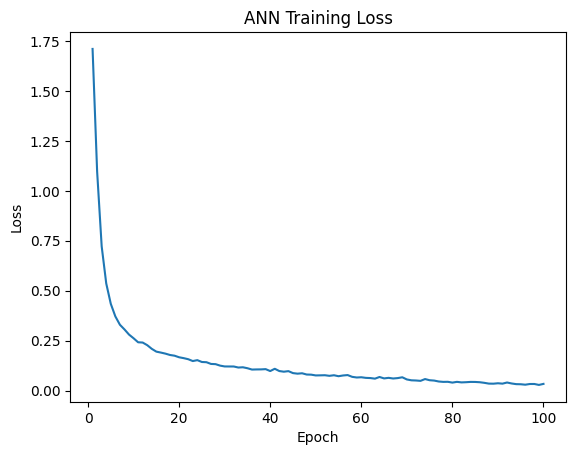

In [41]:
plt.plot(range(1, epochs + 1), loss_values)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training Loss")

plt.show()

In [42]:
# Testing the ANN

model.eval()

correct = 0
total = 0

all_predictions = []
all_actual = []

with torch.no_grad():

    for xb, yb in test_loader:

        outputs = model(xb)

        _, predicted = torch.max(outputs, 1)

        total += yb.size(0)
        correct += (predicted == yb).sum().item()

        all_predictions.extend(predicted.numpy())
        all_actual.extend(yb.numpy())


accuracy = correct / total * 100

print("Test Accuracy:", accuracy, "%")

Test Accuracy: 93.88888888888889 %


In [43]:
y_test.shape

(180,)

In [44]:
# Convert numbers back to class names

actual_classes = le.inverse_transform(all_actual)
predicted_classes = le.inverse_transform(all_predictions)

for i in range(20):
    print("Actual:", actual_classes[i],
          "Predicted:", predicted_classes[i])

Actual: DOKOL Predicted: DOKOL
Actual: SAFAVI Predicted: SAFAVI
Actual: DOKOL Predicted: DOKOL
Actual: SOGAY Predicted: SOGAY
Actual: BERHI Predicted: BERHI
Actual: DOKOL Predicted: DOKOL
Actual: IRAQI Predicted: IRAQI
Actual: DOKOL Predicted: DOKOL
Actual: DOKOL Predicted: DOKOL
Actual: DEGLET Predicted: DEGLET
Actual: DEGLET Predicted: DEGLET
Actual: DOKOL Predicted: DOKOL
Actual: DOKOL Predicted: DOKOL
Actual: DOKOL Predicted: DOKOL
Actual: ROTANA Predicted: ROTANA
Actual: ROTANA Predicted: ROTANA
Actual: SOGAY Predicted: SOGAY
Actual: SAFAVI Predicted: SAFAVI
Actual: SOGAY Predicted: SOGAY
Actual: DEGLET Predicted: DEGLET


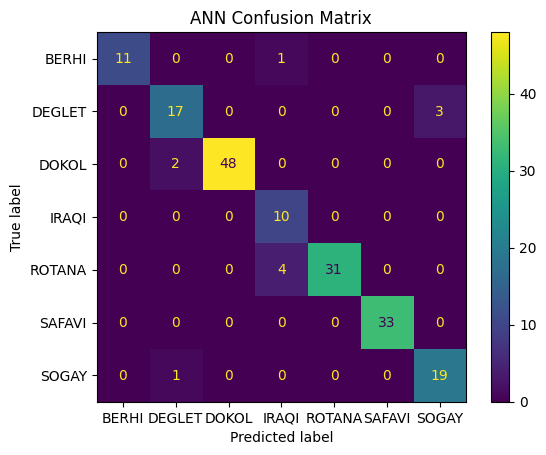

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_actual, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot()

plt.title("ANN Confusion Matrix")
plt.show()